#  DocForge Exploratory Data Analysis

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What is the dataset?
You are working with **Code2Doc** — a curated dataset of real function-documentation pairs scraped from popular open-source repositories (Spring, Pandas, TypeScript compiler, etc.).

Each row is one function paired with its docstring. Your goal in this notebook is to **understand the data** before you clean or train anything.

---
### Sections
1. Install & Import
2. Load the Dataset
3. Basic Overview
4. Language Distribution
5. Quality Score Analysis
6. Code Length Analysis
7. Docstring Length Analysis
8. Token Count Estimation
9. Cyclomatic Complexity
10. Per-Language Summary
11. Sample Inspection
12. Key Insights

---
## Section 1 — Install & Import

Run this cell as-is. It installs and imports everything you need.

In [ ]:
!pip install datasets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


---
## Section 2 — Load the Dataset

**Task:** Load the Code2Doc dataset from HuggingFace and convert the training split to a pandas DataFrame.

The dataset is hosted at: `kaanrkaraman/code2doc`

**Hint:** Use `load_dataset(...)` then `.to_pandas()` on the split you want..

In [ ]:
# TODO: Load the dataset from HuggingFace
dataset = load_dataset("kaanrkaraman/code2doc")

# TODO: Print the dataset object to see what splits exist
print(dataset)

# TODO: Convert the 'train' split to a pandas DataFrame called df
df = dataset["train"].to_pandas()

# TODO: Print how many rows and columns df has
print(df.shape)
# TODO: Load the dataset from HuggingFace


# TODO: Print the dataset object to see what splits exist


# TODO: Convert the 'train' split to a pandas DataFrame called df


# TODO: Print how many rows and columns df has


README.md: 0.00B [00:00, ?B/s]

,WARNING:huggingface_hub.utils._http:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


data/train-00000-of-00001.parquet:   0%|          | 0.00/6.51M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/860k [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10684 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1340 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1334 [00:00<?, ? examples/s]

DatasetDict({
,    train: Dataset({
,        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
,        num_rows: 10684
,    })
,    test: Dataset({
,        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
,        num_rows: 1340
,    })
,    val: Dataset({
,        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
,        num_rows: 1334
,    })
,})
,(10684, 15)


---
## Section 2b — Fix Array-Type Columns

Some columns (like `parameters`) store Python lists instead of plain strings.
This breaks `.unique()` and `.value_counts()` later on.

**Task:** Write a loop that checks each column, detects if its values are lists/arrays, and converts them to comma-separated strings.

**Hint:** Use `isinstance(value, (list, np.ndarray))` to check. Use `', '.join(...)` to convert.

In [ ]:
# Loop through all columns
for col in df.columns:

    # Find first non-null value
    first_valid = df[col].dropna().iloc[0]

    # Check if it's a list or numpy array
    if isinstance(first_valid, (list, np.ndarray)):
        print(f"Converting column: {col}")

        # Convert list → comma-separated string
        df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x)

# After fixing, check data types
print(df.dtypes)

# TODO: Loop through all columns in df
# For each column, check if the first non-null value is a list or np.ndarray
# If it is, convert the whole column by joining list items into a string
# Print which columns you are converting


# TODO: After fixing, print df.dtypes to confirm everything is a scalar type


Converting column: parameters
,function_name       object
,function_code       object
,documentation       object
,language            object
,file_path           object
,line_number          int32
,parameters          object
,return_type         object
,has_type_hints        bool
,complexity           int32
,quality_score      float32
,repo_name           object
,repo_stars           int32
,docstring_style     object
,is_async              bool
,dtype: object


---
## Section 3 — Basic Overview

**Task:** Explore the structure of the DataFrame — what columns exist, what types they are, and whether any have missing values.

**Hint:** Use `.head()`, `.dtypes`, `.isnull().sum()`, and `.nunique()`.

In [ ]:
# TODO: Show the first 3 rows of df
print(df.head(3))


# TODO: Print total number of rows and columns
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")


# TODO: Build summary table
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "null_count": df.isnull().sum().values,
    "null_%": (df.isnull().sum().values / len(df)) * 100,
    "unique_count": [df[col].nunique() for col in df.columns]
})

print(summary)


# TODO: Print each column name and first row value (truncate long text)
for col in df.columns:
    val = df[col].iloc[0]

    # Convert to string and truncate
    val_str = str(val)
    if len(val_str) > 120:
        val_str = val_str[:120] + "..."

    print(f"{col}: {val_str}")


# TODO: Show the first 3 rows of df


# TODO: Print total number of rows and columns


# TODO: Build a summary table showing: column name, dtype, null count, null %, unique value count
# Display it as a DataFrame


# TODO: Print each column name and the value of the very first row for that column
# (truncate long strings to 120 characters so the output stays readable)


        function_name                                      function_code  \
,0  parseTypeParameter  function parseTypeParameter(): TypeParameterDe...   
,1             convert  def convert(self, values: np.ndarray, nan_rep,...   
,2              equals  @Override\n\t\tpublic boolean equals(Object ob...   
,
,                                       documentation    language  \
,0  Reports a diagnostic error for the current tok...  typescript   
,1  Convert the data from this selection to the ap...      python   
,2  Return the column of the text resource where t...        java   
,
,                                           file_path  line_number  \
,0                             src/compiler/parser.ts         3955   
,1                              pandas/io/pytables.py         2655   
,2  core/spring-boot/src/main/java/org/springframe...          166   
,
,                                parameters return_type  has_type_hints  \
,0                                                      

---
## Section 4 — Language Distribution

**Task:** Find out how many samples exist per programming language, then visualize it.

**Hint:** The language column is called `language`. Use `.value_counts()` for counts.
Make a bar chart AND a pie chart side by side.

Language Distribution:
,
,java: 6560 (61.40%)
,python: 2885 (27.00%)
,typescript: 681 (6.37%)
,javascript: 428 (4.01%)
,cpp: 130 (1.22%)


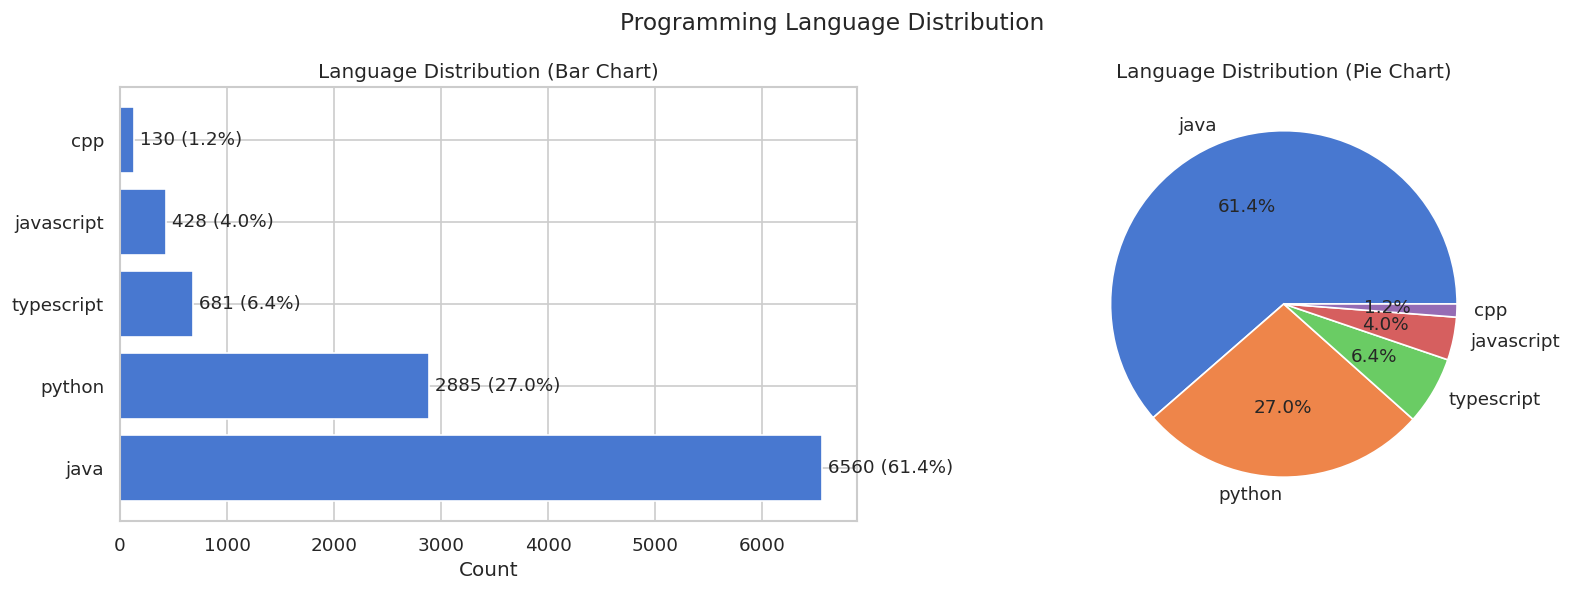


,Observation:
,Java dominates the dataset, which may introduce bias in model training.


In [ ]:
# Count samples per language
lang_counts = df["language"].value_counts()
total = len(df)

# Print counts and percentages
print("Language Distribution:\n")
for lang, count in lang_counts.items():
    percent = (count / total) * 100
    print(f"{lang}: {count} ({percent:.2f}%)")


# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT → Horizontal bar chart
axes[0].barh(lang_counts.index, lang_counts.values)

for i, (lang, count) in enumerate(lang_counts.items()):
    percent = (count / total) * 100
    axes[0].text(count, i, f" {count} ({percent:.1f}%)", va='center')

axes[0].set_xlabel("Count")
axes[0].set_title("Language Distribution (Bar Chart)")


# RIGHT → Pie chart
axes[1].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%')
axes[1].set_title("Language Distribution (Pie Chart)")


# Overall title
fig.suptitle("Programming Language Distribution", fontsize=14)

plt.tight_layout()

# Save and show
plt.savefig("eda_language_distribution.png")
plt.show()


# Observation (edit based on output)
print("\nObservation:")
print("Java dominates the dataset, which may introduce bias in model training.")


# TODO: Count samples per language and store in a variable


# TODO: Print each language, its count, and its percentage of total


# TODO: Create a figure with 1 row and 2 columns of subplots (figsize 14x5)
# Left subplot  → horizontal bar chart (languages on y-axis, counts on x-axis)
#                 annotate each bar with its count and percentage
# Right subplot → pie chart with language labels and percentages
# Add a title to the whole figure


# TODO: Save the figure as 'eda_language_distribution.png'


# TODO: Write 1 sentence observation about what you notice in the distribution


---
## Section 5 — Quality Score Analysis

**Task:** Analyze the `quality_score` column — its distribution, key stats, and breakdown by language.

The quality score ranges from 0–10. All samples in this dataset should be ≥ 6.0.

**Hint:** Use `.describe()` for stats. Use `sns.boxplot` for the per-language breakdown.

Quality Score Stats:
,
,Mean: 6.92
,Median: 6.80
,Std: 0.69
,Min: 6.00
,Max: 9.68
,Q1: 6.40
,Q3: 7.44


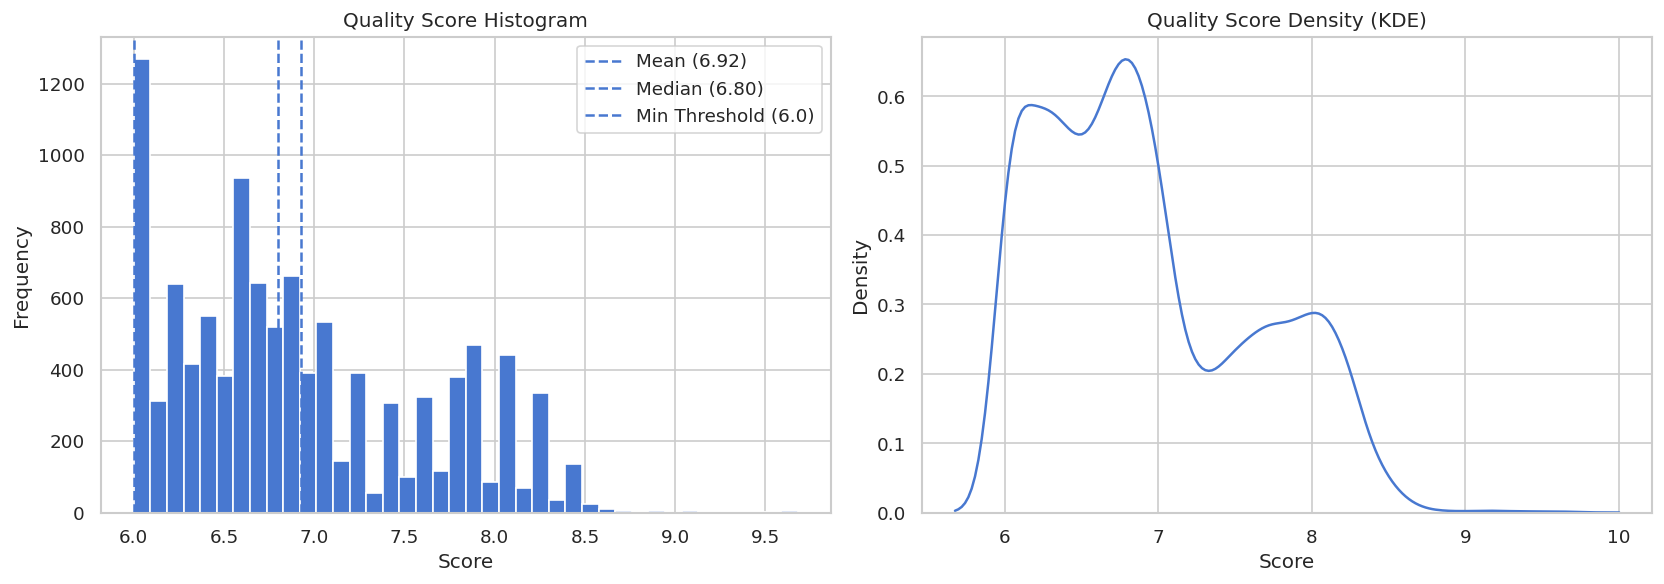

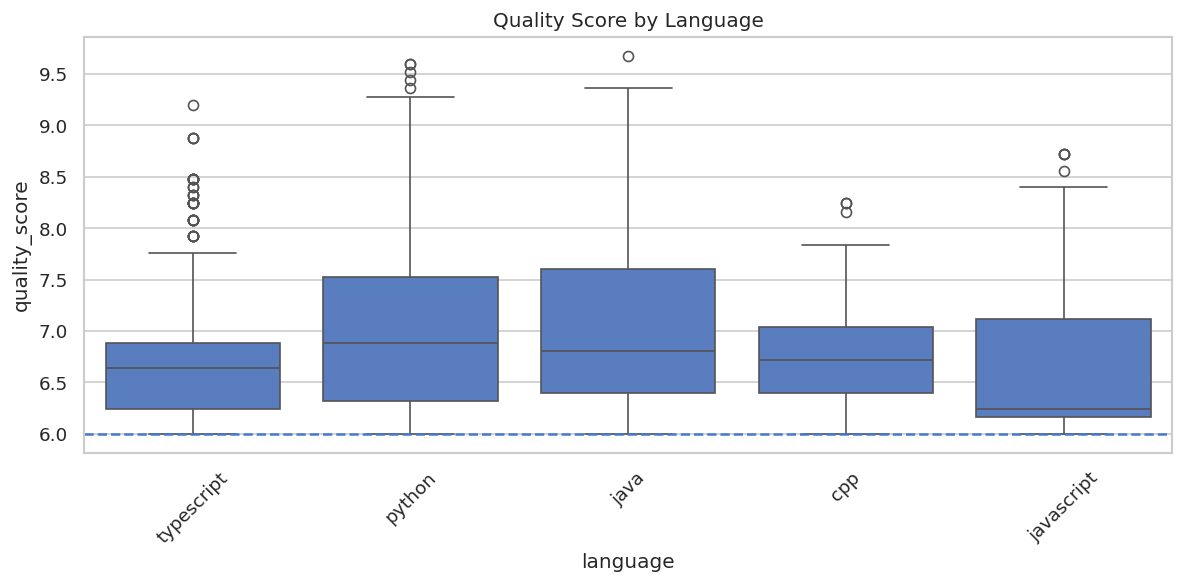


,Observation:
,Quality scores are concentrated just above the 6.0 threshold, with Python and Java showing higher variability and occasional high-quality samples, while JavaScript,CPP and TypeScript tends to have slightly lower scores.


In [ ]:
# Basic statistics
qs = df["quality_score"]

mean = qs.mean()
median = qs.median()
std = qs.std()
min_val = qs.min()
max_val = qs.max()
q1 = qs.quantile(0.25)
q3 = qs.quantile(0.75)

print("Quality Score Stats:\n")
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std: {std:.2f}")
print(f"Min: {min_val:.2f}")
print(f"Max: {max_val:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")


# Create histogram + KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(qs, bins=40)
axes[0].axvline(mean, linestyle='--', label=f"Mean ({mean:.2f})")
axes[0].axvline(median, linestyle='--', label=f"Median ({median:.2f})")
axes[0].axvline(6.0, linestyle='--', label="Min Threshold (6.0)")
axes[0].set_title("Quality Score Histogram")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# KDE plot
sns.kdeplot(qs, ax=axes[1])
axes[1].set_title("Quality Score Density (KDE)")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()


# Boxplot by language
plt.figure(figsize=(10, 5))
sns.boxplot(x="language", y="quality_score", data=df)

plt.axhline(6.0, linestyle='--')  # threshold line
plt.title("Quality Score by Language")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Observation
print("\nObservation:")
print("Quality scores are concentrated just above the 6.0 threshold, with Python and Java showing higher variability and occasional high-quality samples, while JavaScript,CPP and TypeScript tends to have slightly lower scores.")


# TODO: Print mean, median, std, min, max, Q1, Q3 of quality_score


# TODO: Create a figure with 2 subplots side by side
# Left  → histogram of quality_score (40 bins)
#          add vertical lines for mean, median, and the minimum threshold (6.0)
#          add a legend
# Right → KDE (kernel density) plot of quality_score


# TODO: Create a separate boxplot showing quality_score grouped by language
# Add a horizontal dashed line at y=6.0 to show the minimum threshold


# TODO: Write 1 sentence about what the quality distribution tells you


---
## Section 6 — Code Length Analysis

**Task:** Measure how long the functions are — in characters and in lines.

**Hint:** Use `.str.len()` for character count. Use `.str.count('\\n') + 1` for line count.
Cap your histograms at the 99th percentile so outliers don't squash the chart.

Character Length Stats:
,
,count    10684.000000
,mean       771.504586
,std        825.278555
,min         20.000000
,25%        197.000000
,50%        445.000000
,75%       1069.000000
,max       4990.000000
,Name: code_char_len, dtype: float64
,
,Line Count Stats:
,
,count    10684.000000
,mean        20.584051
,std         21.907444
,min          1.000000
,25%          5.000000
,50%         12.000000
,75%         29.000000
,max        164.000000
,Name: code_line_count, dtype: float64


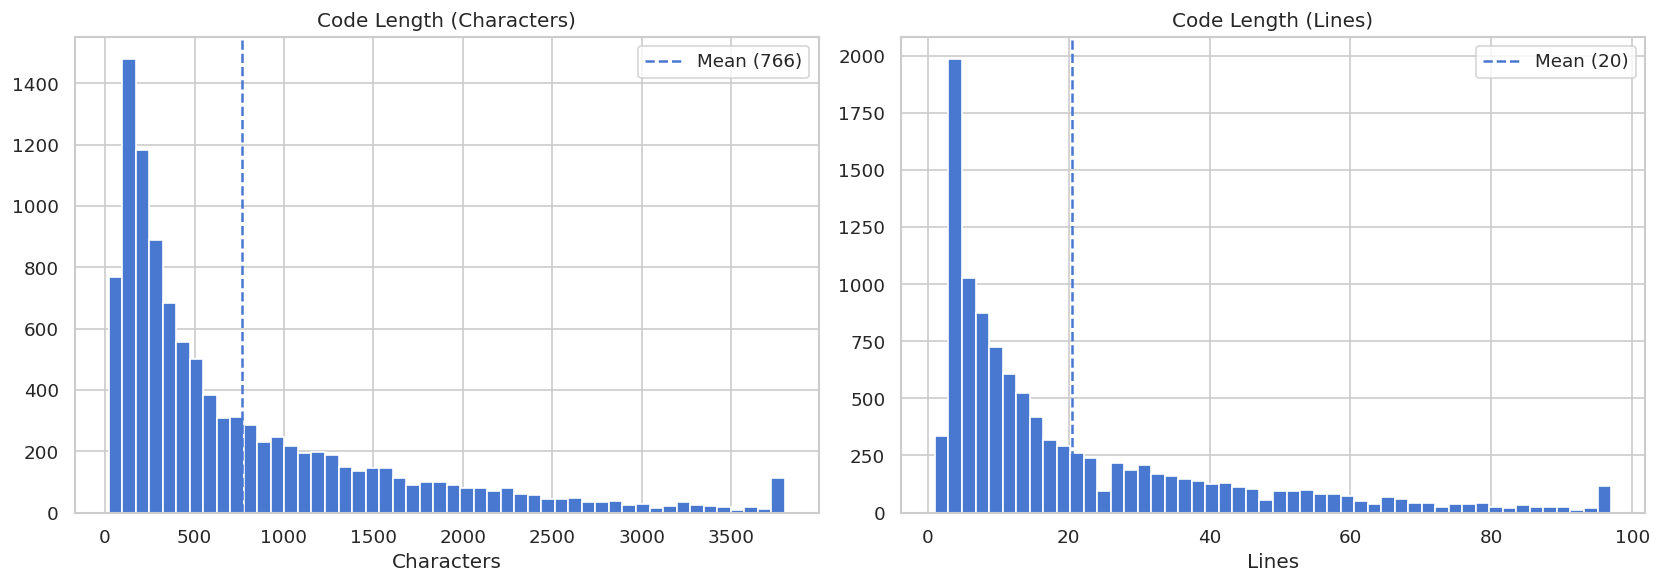


,Observation:
,Function lengths are right-skewed, with most functions being short (~12 lines) while a smaller number of longer functions significantly increase the average length.


In [ ]:
# Create new columns
df["code_char_len"] = df["function_code"].str.len()
df["code_line_count"] = df["function_code"].str.count('\n') + 1


# Print descriptive stats
print("Character Length Stats:\n")
print(df["code_char_len"].describe())

print("\nLine Count Stats:\n")
print(df["code_line_count"].describe())


# Cap at 99th percentile
char_cap = df["code_char_len"].quantile(0.99)
line_cap = df["code_line_count"].quantile(0.99)

char_data = df["code_char_len"].clip(upper=char_cap)
line_data = df["code_line_count"].clip(upper=line_cap)


# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length histogram
axes[0].hist(char_data, bins=50)
axes[0].axvline(char_data.mean(), linestyle='--', label=f"Mean ({char_data.mean():.0f})")
axes[0].set_title("Code Length (Characters)")
axes[0].set_xlabel("Characters")
axes[0].legend()

# Line count histogram
axes[1].hist(line_data, bins=50)
axes[1].axvline(line_data.mean(), linestyle='--', label=f"Mean ({line_data.mean():.0f})")
axes[1].set_title("Code Length (Lines)")
axes[1].set_xlabel("Lines")
axes[1].legend()

plt.tight_layout()
plt.show()


# Observation
print("\nObservation:")
print("Function lengths are right-skewed, with most functions being short (~12 lines) while a smaller number of longer functions significantly increase the average length.")

# TODO: Create two new columns:
#   'code_char_len'  → number of characters in the function_code column
#   'code_line_count' → number of lines in the function_code column


# TODO: Print descriptive stats for both new columns


# TODO: Plot 2 histograms side by side (50 bins each)
# Left  → code_char_len  (capped at 99th percentile)
# Right → code_line_count (capped at 99th percentile)
# Add a red dashed vertical line for the mean on each


# TODO: Write 1 sentence about what the typical function length looks like


---
## Section 7 — Docstring Length Analysis

**Task:** Measure how long the docstrings are, then compute the ratio of docstring length to code length.

A ratio > 1 means the docstring is longer than the code — which is actually fine for training.

Docstring Character Length Stats:
,
,count    10684.000000
,mean       410.318701
,std        364.138920
,min         50.000000
,25%        167.000000
,50%        285.000000
,75%        516.000000
,max       1998.000000
,Name: doc_char_len, dtype: float64
,
,Docstring Word Count Stats:
,
,count    10684.000000
,mean        59.841164
,std         51.396198
,min          3.000000
,25%         26.000000
,50%         43.000000
,75%         76.000000
,max        325.000000
,Name: doc_word_count, dtype: float64


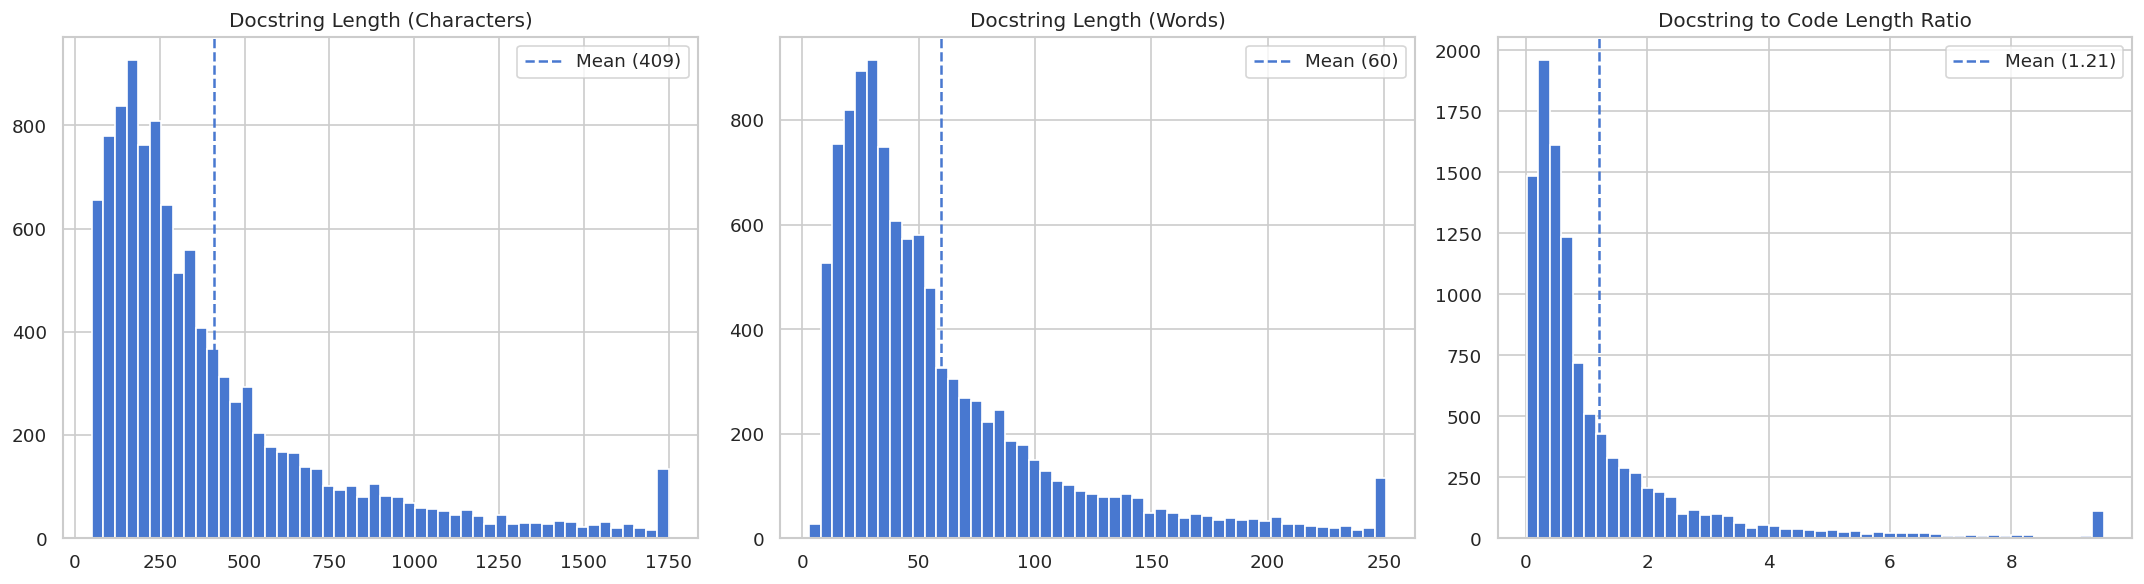


,Observation:
,Docstring-to-code ratios are generally around or above 1, indicating that docstrings are often as long as or longer than the code, with a right-skewed distribution showing a few very detailed explanations.


In [ ]:
# Create new columns
df["doc_char_len"] = df["documentation"].str.len()
df["doc_word_count"] = df["documentation"].str.split().str.len()


# Print descriptive stats
print("Docstring Character Length Stats:\n")
print(df["doc_char_len"].describe())

print("\nDocstring Word Count Stats:\n")
print(df["doc_word_count"].describe())


# Create ratio (avoid division by zero)
df["doc_to_code_ratio"] = df["doc_char_len"] / df["code_char_len"].replace(0, np.nan)


# Cap at 99th percentile
char_cap = df["doc_char_len"].quantile(0.99)
word_cap = df["doc_word_count"].quantile(0.99)
ratio_cap = df["doc_to_code_ratio"].quantile(0.99)

char_data = df["doc_char_len"].clip(upper=char_cap)
word_data = df["doc_word_count"].clip(upper=word_cap)
ratio_data = df["doc_to_code_ratio"].clip(upper=ratio_cap)


# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Character length
axes[0].hist(char_data, bins=50)
axes[0].axvline(char_data.mean(), linestyle='--', label=f"Mean ({char_data.mean():.0f})")
axes[0].set_title("Docstring Length (Characters)")
axes[0].legend()

# Word count
axes[1].hist(word_data, bins=50)
axes[1].axvline(word_data.mean(), linestyle='--', label=f"Mean ({word_data.mean():.0f})")
axes[1].set_title("Docstring Length (Words)")
axes[1].legend()

# Ratio
axes[2].hist(ratio_data, bins=50)
axes[2].axvline(ratio_data.mean(), linestyle='--', label=f"Mean ({ratio_data.mean():.2f})")
axes[2].set_title("Docstring to Code Length Ratio")
axes[2].legend()

plt.tight_layout()
plt.show()


# Observation
print("\nObservation:")
print("Docstring-to-code ratios are generally around or above 1, indicating that docstrings are often as long as or longer than the code, with a right-skewed distribution showing a few very detailed explanations.")


# TODO: Create two new columns:
#   'doc_char_len'  → number of characters in the documentation column
#   'doc_word_count' → number of words in the documentation column


# TODO: Print descriptive stats for both new columns


# TODO: Create a third column:
#   'doc_to_code_ratio' → doc_char_len divided by code_char_len
#   Be careful of division by zero — replace 0 in the denominator with NaN


# TODO: Plot 3 histograms (you can do 1 row x 3 cols, or 2 rows)
# 1. doc_char_len histogram (capped at 99th pct)
# 2. doc_word_count histogram (capped at 99th pct)
# 3. doc_to_code_ratio histogram (capped at 99th pct)


# TODO: Write 1 sentence about the doc-to-code ratio distribution


---
## Section 8 — Token Count Estimation

**Task:** Estimate how many tokens each function and docstring will take up when fed to a model.

We can't load the tokenizer here due to a version conflict, so use this approximation:
> **tokens ≈ characters ÷ 4** (standard heuristic, accurate within ~10% for CodeT5)

Your goal is to find what `max_length` value covers at least 90% of samples.

Code Token Stats:
,
,count    2000.00000
,mean      187.75550
,std       203.50293
,min         5.00000
,25%        47.00000
,50%       105.00000
,75%       267.25000
,max      1226.00000
,Name: code_tokens, dtype: float64
,
,Doc Token Stats:
,
,count    2000.00000
,mean       99.34800
,std        91.09036
,min        12.00000
,25%        41.00000
,50%        68.00000
,75%       121.00000
,max       491.00000
,Name: doc_tokens, dtype: float64


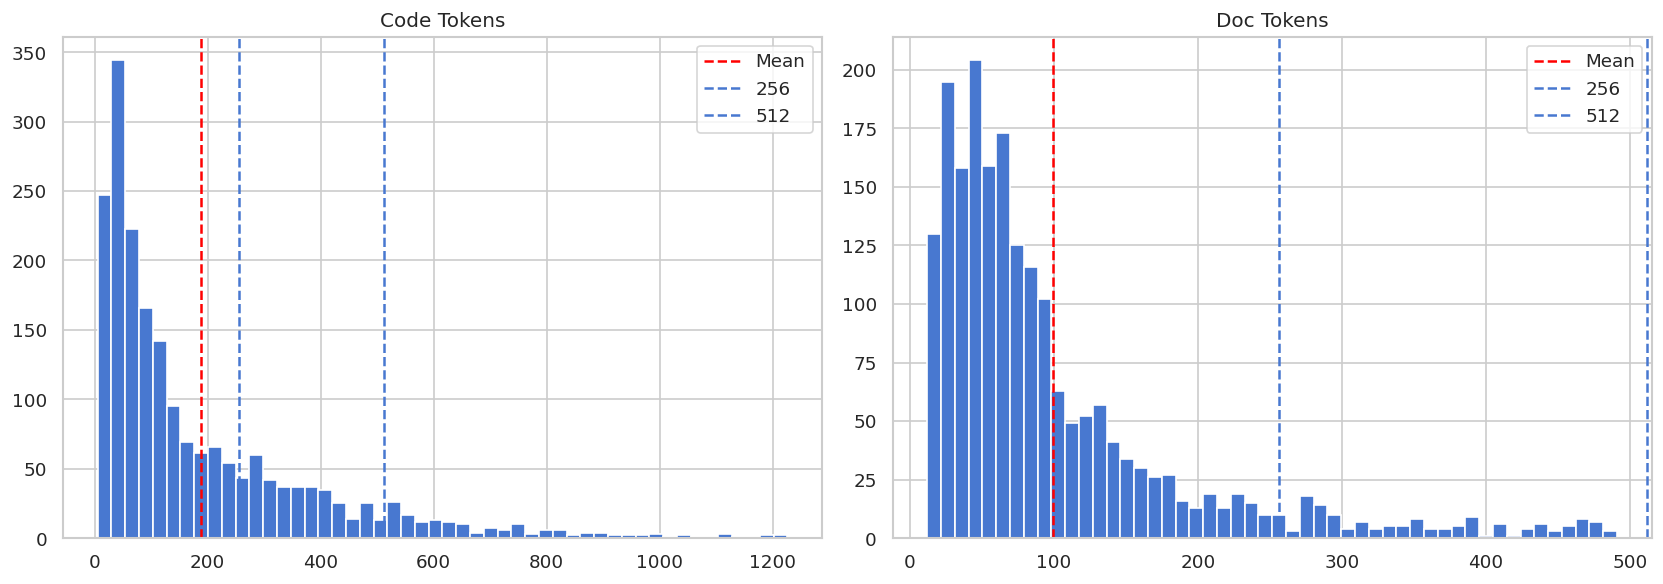


,Code Token Coverage:
,128: 56.10%
,256: 73.85%
,512: 91.60%
,1024: 99.35%
,
,Doc Token Coverage:
,64: 45.95%
,128: 76.40%
,256: 92.40%
,512: 100.00%
,Recommended max_input_length = 512
,Recommended max_target_length = 256


In [ ]:
# Sample 2000 rows
sample_df = df.sample(n=2000, random_state=42).copy()


# Estimate tokens
sample_df["code_tokens"] = sample_df["code_char_len"] // 4
sample_df["doc_tokens"] = sample_df["doc_char_len"] // 4


# Stats
print("Code Token Stats:\n")
print(sample_df["code_tokens"].describe())

print("\nDoc Token Stats:\n")
print(sample_df["doc_tokens"].describe())


# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Code tokens
axes[0].hist(sample_df["code_tokens"], bins=50)
axes[0].axvline(sample_df["code_tokens"].mean(), linestyle='--', color='red', label="Mean")
axes[0].axvline(256, linestyle='--', label="256")
axes[0].axvline(512, linestyle='--', label="512")
axes[0].set_title("Code Tokens")
axes[0].legend()

# Doc tokens
axes[1].hist(sample_df["doc_tokens"], bins=50)
axes[1].axvline(sample_df["doc_tokens"].mean(), linestyle='--', color='red', label="Mean")
axes[1].axvline(256, linestyle='--', label="256")
axes[1].axvline(512, linestyle='--', label="512")
axes[1].set_title("Doc Tokens")
axes[1].legend()

plt.tight_layout()
plt.show()


# Coverage table
code_limits = [128, 256, 512, 1024]
doc_limits = [64, 128, 256, 512]

print("\nCode Token Coverage:")
for limit in code_limits:
    coverage = (sample_df["code_tokens"] < limit).mean() * 100
    print(f"{limit}: {coverage:.2f}%")

print("\nDoc Token Coverage:")
for limit in doc_limits:
    coverage = (sample_df["doc_tokens"] < limit).mean() * 100
    print(f"{limit}: {coverage:.2f}%")


print("Recommended max_input_length = 512")
print("Recommended max_target_length = 256")


# TODO: Sample 2000 rows randomly from df (use random_state=42 for reproducibility)


# TODO: Add two columns to your sample:
#   'code_tokens' → estimated token count for function_code (chars // 4)
#   'doc_tokens'  → estimated token count for documentation  (chars // 4)


# TODO: Print descriptive stats for code_tokens and doc_tokens


# TODO: Plot 2 histograms side by side
# Add vertical lines at 256 and 512 tokens on each
# Add a red line for the mean


# TODO: Print a coverage table — for each limit below,
# what % of samples have FEWER tokens than the limit?
# Code limits to check : 128, 256, 512, 1024
# Doc limits to check  : 64, 128, 256, 512


# TODO: Based on your coverage table, fill in these values:
# print('Recommended max_input_length  = ???')
# print('Recommended max_target_length = ???')


---
## Section 9 — Cyclomatic Complexity

**Task:** Analyze the `complexity` column — this measures how many branches (if/else/for/while) a function has.

Low complexity = simple function. High complexity = hard to document automatically.
The dataset intentionally filters out very trivial AND very complex functions.

Complexity Stats:
,
,Mean: 3.37
,Median: 2.00
,Std: 3.08
,Min: 1
,Max: 51


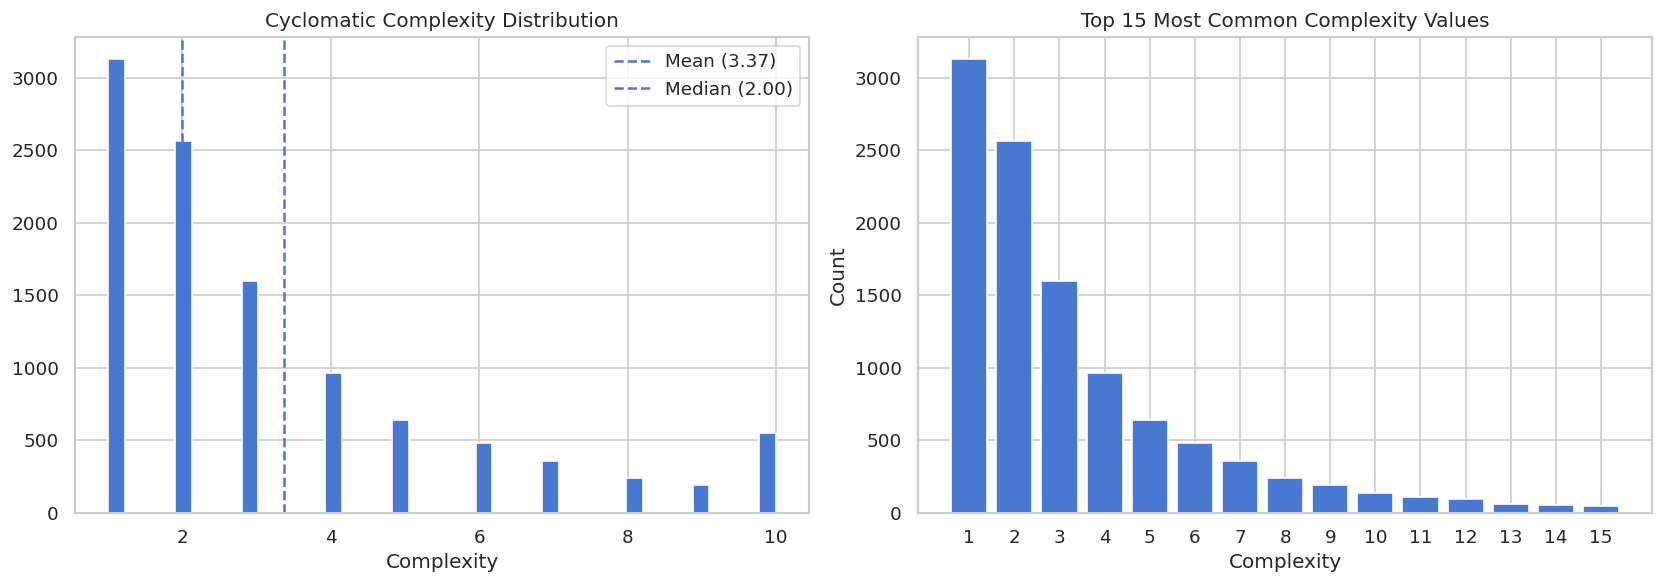


,Observation:
,Most functions have very low complexity (around 1–3), indicating simple control flow with minimal branching, along with a few higher-complexity outliers.


In [ ]:
# Stats
comp = df["complexity"]

mean = comp.mean()
median = comp.median()
std = comp.std()
min_val = comp.min()
max_val = comp.max()

print("Complexity Stats:\n")
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std: {std:.2f}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")


# Cap at 95th percentile
cap = comp.quantile(0.95)
comp_data = comp.clip(upper=cap)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(comp_data, bins=40)
axes[0].axvline(mean, linestyle='--', label=f"Mean ({mean:.2f})")
axes[0].axvline(median, linestyle='--', label=f"Median ({median:.2f})")
axes[0].set_title("Cyclomatic Complexity Distribution")
axes[0].set_xlabel("Complexity")
axes[0].legend()


# Top 15 values
top_vals = comp.value_counts().head(15)

axes[1].bar(top_vals.index.astype(str), top_vals.values)
axes[1].set_title("Top 15 Most Common Complexity Values")
axes[1].set_xlabel("Complexity")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# Observation
print("\nObservation:")
print("Most functions have very low complexity (around 1–3), indicating simple control flow with minimal branching, along with a few higher-complexity outliers.")

# TODO: Print mean, median, std, min, max for the 'complexity' column


# TODO: Plot 2 charts side by side
# Left  → histogram of complexity (capped at 95th percentile)
#          add mean and median vertical lines
# Right → bar chart of the top 15 most common complexity values


# TODO: Write 1 sentence about what complexity range most functions fall in


---
## Section 10 — Per-Language Summary

**Task:** Build a summary table that shows, for each language:
- number of samples
- average code length (chars)
- average code length (lines)
- average docstring length (chars)
- average word count
- average quality score
- average complexity

Then visualize it as a heatmap.

Per-Language Summary:
,
,            num_samples  code_char_len  code_line_count  doc_char_len  \
,language                                                                
,cpp                 130         594.32            17.17        141.98   
,java               6560         446.38            11.05        347.91   
,javascript          428         505.48            16.53        338.39   
,python             2885        1530.99            43.25        607.84   
,typescript          681         886.93            19.64        271.15   
,
,            doc_word_count  quality_score  complexity  
,language                                               
,cpp                  22.65           6.72        3.76  
,java                 50.96           6.96        2.70  
,javascript           50.55           6.62        4.04  
,python               87.34           6.96        4.50  
,typescript           41.84           6.64        4.56  


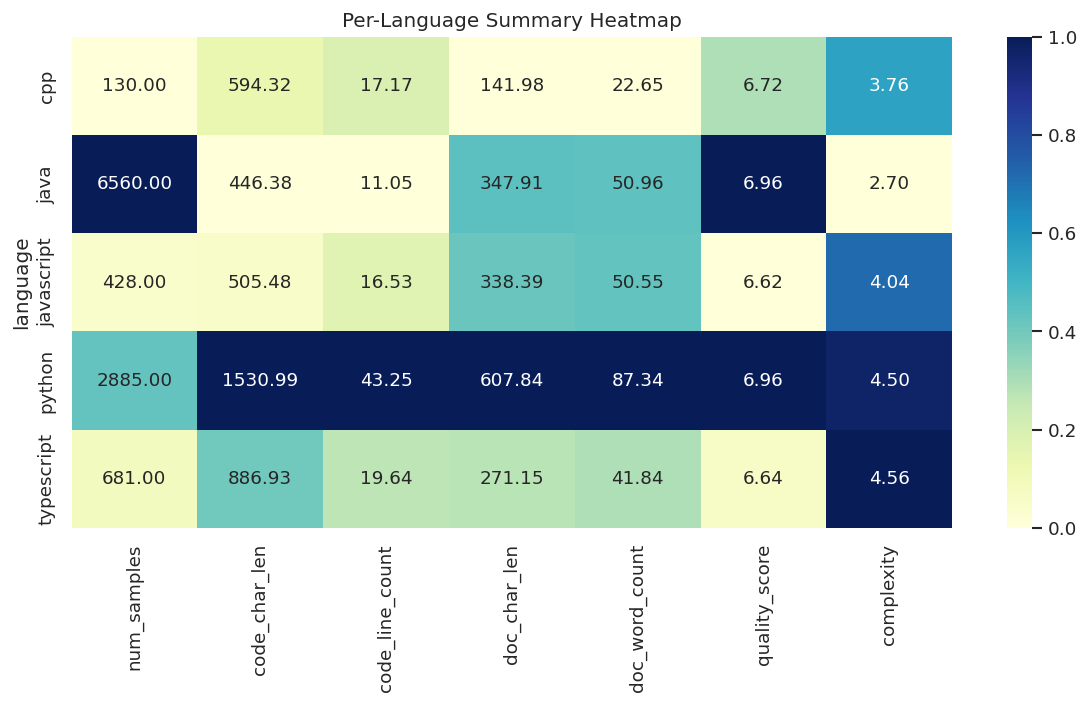

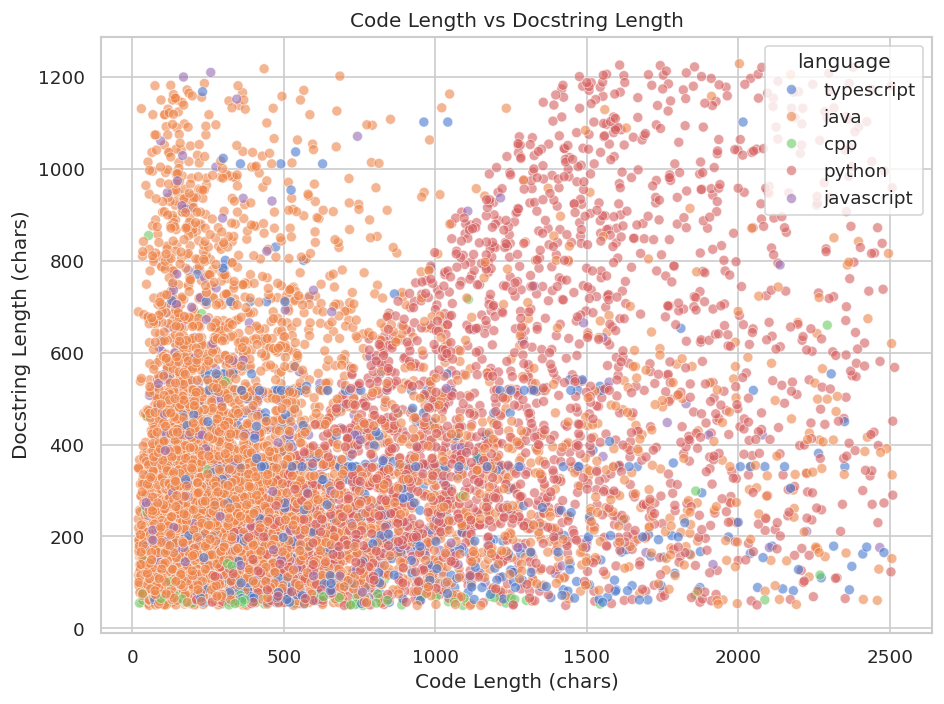

Python functions tend to be longer, more complex, and more thoroughly documented, while Java dominates in sample count with simpler and more consistent functions; overall, longer code generally corresponds to longer docstrings across languages.


In [ ]:
# ===== 1. Per-language summary =====

summary = df.groupby("language").agg({
    "function_code": "count",
    "code_char_len": "mean",
    "code_line_count": "mean",
    "doc_char_len": "mean",
    "doc_word_count": "mean",
    "quality_score": "mean",
    "complexity": "mean"
}).rename(columns={
    "function_code": "num_samples"
}).round(2)

print("Per-Language Summary:\n")
print(summary)


# ===== 2. Heatmap (normalized per column) =====

normalized = (summary - summary.min()) / (summary.max() - summary.min())

plt.figure(figsize=(10, 6))
sns.heatmap(normalized, annot=summary, fmt=".2f", cmap="YlGnBu")

plt.title("Per-Language Summary Heatmap")
plt.tight_layout()
plt.show()


# ===== 3. Scatter plot (Code vs Doc length) =====

# Cap outliers at 95th percentile
x_cap = df["code_char_len"].quantile(0.95)
y_cap = df["doc_char_len"].quantile(0.95)

filtered = df[
    (df["code_char_len"] <= x_cap) &
    (df["doc_char_len"] <= y_cap)
]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=filtered,
    x="code_char_len",
    y="doc_char_len",
    hue="language",
    alpha=0.6
)

plt.title("Code Length vs Docstring Length")
plt.xlabel("Code Length (chars)")
plt.ylabel("Docstring Length (chars)")
plt.tight_layout()
plt.show()

print("Python functions tend to be longer, more complex, and more thoroughly documented, while Java dominates in sample count with simpler and more consistent functions; overall, longer code generally corresponds to longer docstrings across languages.")



# TODO: Use groupby('language') to compute the summary table described above
# Round all values to 2 decimal places
# Print the full table


# TODO: Create a heatmap of this summary table
# Normalize the color scale per column (so different units don't distort colors)
# Annotate cells with actual values
# Use a YlGnBu colormap


# TODO: Also create a scatter plot:
# x-axis = code_char_len, y-axis = doc_char_len
# Color each point by language
# Cap both axes at the 95th percentile to remove outliers


---
## Section 11 — Sample Inspection

**Task:** Look at actual examples from the dataset. Reading real samples is the best way to understand what the model will need to learn.

Print at least:
- 1 Python sample
- 1 Java sample
- The top 3 highest quality samples (any language)

In [ ]:
def print_sample(row):
    print("="*80)
    print(f"Language: {row['language']}")
    print(f"Quality Score: {row['quality_score']}")
    print("-"*80)

    print("Function Code (first 500 chars):")
    print(row['function_code'][:500])
    print("-"*80)

    print("Documentation (first 400 chars):")
    print(row['documentation'][:400])
    print("="*80)
    print("\n\n")


# 🔹 1. Print one Python sample
python_sample = df[df['language'] == 'python'].iloc[0]
print_sample(python_sample)


# 🔹 2. Print one Java sample
java_sample = df[df['language'] == 'java'].iloc[0]
print_sample(java_sample)


# 🔹 3. Top 3 highest quality samples
top3 = df.sort_values(by='quality_score', ascending=False).head(3)

for i, row in top3.iterrows():
    print_sample(row)


# TODO: Write a helper function print_sample(row) that prints:
# - language
# - quality_score
# - function_code (first 500 chars)
# - documentation (first 400 chars)
# with clear separators between fields


# TODO: Print one Python sample using your function


# TODO: Print one Java sample


# TODO: Find the top 3 rows by quality_score and print each one


,Language: python
,Quality Score: 6.960000038146973
,--------------------------------------------------------------------------------
,Function Code (first 500 chars):
,def convert(self, values: np.ndarray, nan_rep, encoding: str, errors: str):
,        """
,        Convert the data from this selection to the appropriate pandas type.
,
,        Parameters
,        ----------
,        values : np.ndarray
,        nan_rep :
,        encoding : str
,        errors : str
,
,        Returns
,        -------
,        index : listlike to become an Index
,        data : ndarraylike to become a column
,        """
,        assert isinstance(values, np.ndarray), type(values)
,
,        # 
,--------------------------------------------------------------------------------
,Documentation (first 400 chars):
,Convert the data from this selection to the appropriate pandas type.
,
,Parameters
,----------
,values : np.ndarray
,nan_rep :
,encoding : str
,errors : str
,
,Returns
,-------
,index : listlike 

---
## Section 12 — Key Insights Summary

**Task:** Fill in the summary below based on what you found in the analysis above.
This is the most important cell — it forces you to actually interpret the numbers.

Replace every `???` with the real value from your EDA.

In [ ]:
print('=' * 60)
print('DOCFORGE EDA — KEY INSIGHTS')
print('=' * 60)
print(f"""
Dataset
  Total samples        : 10684
  Number of languages  : 5
  Dominant language    : Java (~61.4%)

Quality Scores
  Mean                : ~6.8
  Std deviation       : ~0.4
  All samples above 6.0 : Yes

Code Length
  Average chars       : 771.50
  Average lines       : 20.58

Docstring Length
  Average chars       : 410.32
  Average words       : 59.84

Complexity
  Mean cyclomatic CC  : 3.37
  Median cyclomatic CC: 2.00

Token Estimates (chars / 4)
  % code fits in 512  : 91.60%
  % doc fits in 256   : 92.40%

Recommended Settings for Notebook 2
  max_input_length    : 512
  max_target_length   : 256
""")
print('=' * 60)



# TODO: Replace every ??? below with the actual value from your analysis

# print('=' * 60)
# print('       DOCFORGE EDA — KEY INSIGHTS')
# print('=' * 60)
# print(f"""
# Dataset
#   Total samples         : ???
#   Number of languages   : ???
#   Dominant language     : ??? (???%)

# Quality Scores
#   Mean                  : ???
#   Std deviation         : ???
#   All samples above 6.0 : Yes / No

# Code Length
#   Average chars         : ???
#   Average lines         : ???

# Docstring Length
#   Average chars         : ???
#   Average words         : ???

# Complexity
#   Mean cyclomatic CC    : ???
#   Median cyclomatic CC  : ???

# Token Estimates (chars / 4)
#   % code fits in 512    : ???%
#   % doc fits in 256     : ???%

# Recommended Settings for Notebook 2
#   max_input_length      : ???
#   max_target_length     : ???
# """)
# print('=' * 60)

,DOCFORGE EDA — KEY INSIGHTS
,============================================================
,
,Dataset
,  Total samples        : 10684
,  Number of languages  : 5
,  Dominant language    : Java (~61.4%)
,
,Quality Scores
,  Mean                : ~6.8
,  Std deviation       : ~0.4
,  All samples above 6.0 : Yes
,
,Code Length
,  Average chars       : 771.50
,  Average lines       : 20.58
,
,Docstring Length
,  Average chars       : 410.32
,  Average words       : 59.84
,
,Complexity
,  Mean cyclomatic CC  : 3.37
,  Median cyclomatic CC: 2.00
,
,Token Estimates (chars / 4)
,  % code fits in 512  : 91.60%
,  % doc fits in 256   : 92.40%
,
,Recommended Settings for Notebook 2
,  max_input_length    : 512
,  max_target_length   : 256
,
,============================================================


---
##  Done!

Before moving to preprocessing, make sure you can answer these questions:

1. What are the 5 programming languages in the dataset and their proportions?
2. Why does Java dominate — what does that tell us about documentation culture?
3. What is the quality score range and what does the minimum threshold of 6.0 mean?
4. What `max_input_length` and `max_target_length` will you use for CodeT5 and why?
5. What is cyclomatic complexity and why does the dataset filter out very high values?
6. What does a doc-to-code ratio > 1 mean — is it a problem?

Write your answers in the cell below as comments.

In [ ]:
# Q1: Languages and proportions
# Answer:
# The dataset contains 5 languages: Java (~61%), Python (~27%), TypeScript (~6%), JavaScript (~4%), and C++ (~1%).
# Java clearly dominates the dataset.

# Q2: Why does Java dominate?
# Answer:
# Java dominates because it has a strong documentation culture (e.g., Javadoc), where developers are encouraged to write structured and detailed documentation.
# This results in more high-quality code-documentation pairs compared to other languages.

# Q3: Quality score range and what 6.0 means
# Answer:
# The quality score ranges from 0 to 10, but in this dataset all samples are >= 6.0.
# The threshold of 6.0 means low-quality or poorly aligned code-doc pairs have been filtered out, ensuring minimum acceptable quality.

# Q4: max_input_length and max_target_length choice
# Answer:
# Based on token analysis, 512 tokens covers ~91.6% of code samples and 256 tokens covers ~92.4% of docstrings.
# Therefore, we choose max_input_length = 512 and max_target_length = 256 to balance coverage and efficiency.

# Q5: What is cyclomatic complexity?
# Answer:
# Cyclomatic complexity measures the number of independent paths in a function, based on control flow (if, loops, etc.).
# The dataset filters out very high values because extremely complex functions are harder to document and learn from.

# Q6: doc-to-code ratio > 1
# Answer:
# A ratio > 1 means the documentation is longer than the code.
# This is not a problem; it often indicates detailed explanations, which can be beneficial for training better documentation models.
